## Keras CNN model for A_Z Handwritten Dataset

## Importing libraries

In [1]:
import tensorflow # Import TensorFlow

# Import libraries for data manipulation and visualization
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split # Import library for splitting the dataset

# Import Keras modules for building the CNN model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv2D, MaxPooling2D, Flatten

# Import RMSprop optimizer
from tensorflow.keras.optimizers import RMSprop

# Import evaluation metrics
from sklearn.metrics import classification_report, confusion_matrix

## Loading and Splitting the Dataset

In [2]:
# Load the A–Z Handwritten Alphabet dataset and convert values to float32
dataset = pd.read_csv('A_Z Handwritten Data.csv', header=None).astype('float32') 

# The first column contains the labels (0-25)
alphabet_labels = dataset.iloc[:, 0].values
# The remaining 784 columns are the pixel values
alphabet_images = dataset.iloc[:, 1:].values

# splitting data into train and test sets
train_images, test_images, train_labels_raw, test_labels_raw = train_test_split(alphabet_images, alphabet_labels, test_size=0.2, random_state=42)

## Reshaping and Normalizing the Image Data

In [3]:
from tensorflow.keras import backend as K # Import the Keras backend module

# Check the image data format required by the Keras backend
if K.image_data_format() == 'channels_first':
    # Reshape images to (samples, channels, height, width)
    train_images = train_images.reshape(train_images.shape[0], 1, 28, 28)
    test_images = test_images.reshape(test_images.shape[0], 1, 28, 28)
    # Store the input shape for the CNN model
    input_shape = (1, 28, 28)
else:
    # Reshape images to (samples, height, width, channels)
    train_images = train_images.reshape(train_images.shape[0], 28, 28, 1)
    test_images = test_images.reshape(test_images.shape[0], 28, 28, 1)
    # Store the input shape for the CNN model
    input_shape = (28, 28, 1)

# Convert image data to floating-point format
train_images = train_images.astype('float32')
test_images = test_images.astype('float32')
# Normalize pixel values to the range 0–1
train_images /= 255
test_images /= 255

## One-Hot Encoding the Labels

In [4]:
# Converting the training & Testing labels into one-hot encoded vectors (26 alphabet classes)
train_labels = tensorflow.keras.utils.to_categorical(train_labels_raw, 26)
test_labels = tensorflow.keras.utils.to_categorical(test_labels_raw, 26)

## Visualizing a Sample Training Image

[0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0.]


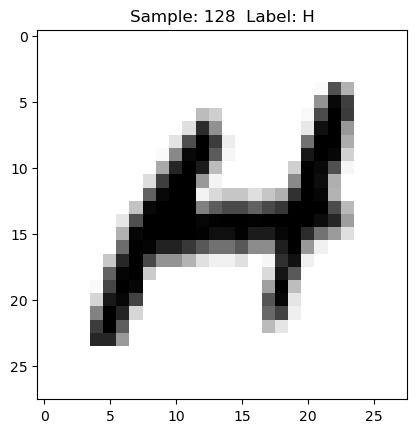

In [5]:
import matplotlib.pyplot as plt # Import the plotting library

# Function to display a sample handwritten alphabet image
def display_sample(num):
    #Print the one-hot array of this sample's label 
    print(train_labels[num])  
    
    label = train_labels[num].argmax(axis=0) # Convert the one-hot encoded label back to its original class label (0–25)
    letter = chr(label + 65) # Convert the numeric label into its corresponding alphabet letter (A–Z)
    #Reshape the 784 values to a 28x28 image
    image = train_images[num].reshape([28,28])
    # Display the sample image with its corresponding alphabet label
    plt.title('Sample: %d  Label: %s' % (num, letter))
    plt.imshow(image, cmap=plt.get_cmap('gray_r'))
    plt.show()
    
display_sample(128) # Display a sample image from the training dataset

## Building the Convolutional Neural Network (CNN)

In [6]:
# Create a Sequential Convolutional Neural Network model
model = Sequential()
# Added first convolutional layer with 32 filters of size 3×3
model.add(Conv2D(32, kernel_size=(3, 3),
                 activation='relu',
                 input_shape=input_shape))
# Added second convolutional layer with 64 filters of size 3×3
model.add(Conv2D(64, (3, 3), activation='relu'))
# Reduce the spatial dimensions using a 2×2 max pooling layer
model.add(MaxPooling2D(pool_size=(2, 2)))
# Dropout to avoid overfitting
model.add(Dropout(0.25))
# Flatten the results to one dimension for passing into our final layer
model.add(Flatten())
# added a fully connected hidden layer with 128 neurons
model.add(Dense(128, activation='relu'))
# another dropout layer to improve generalization
model.add(Dropout(0.5))
# output layer with 26 neurons (one for each alphabet class) with softmax
model.add(Dense(26, activation='softmax'))

C:\Users\yarvi\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Model Summary

In [7]:
model.summary() # Display the architecture and trainable parameters of the Keras CNN

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 24, 24, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 12, 12, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 12, 12, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 9216)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       1,179,776 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 26)                  │           3,354 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,201,946 (4.59 MB)

 Trainable params: 1,201,946 (4.59 MB)

 Non-trainable params: 0 (0.00 B)

## Compiling the CNN Model

In [8]:
# Compile the Keras ANN model by specifying the loss function, optimizer, and evaluation metric
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

## Training the CNN Model

In [9]:
# Train the CNN model using the training dataset
history = model.fit(train_images, train_labels,
                    batch_size=50,
                    epochs=5,
                    verbose=2,
                    validation_data=(test_images, test_labels))

Epoch 1/5
5960/5960 - 346s - 58ms/step - accuracy: 0.9251 - loss: 0.2631 - val_accuracy: 0.9790 - val_loss: 0.0729
Epoch 2/5
5960/5960 - 332s - 56ms/step - accuracy: 0.9647 - loss: 0.1255 - val_accuracy: 0.9843 - val_loss: 0.0564
Epoch 3/5
5960/5960 - 241s - 40ms/step - accuracy: 0.9720 - loss: 0.0985 - val_accuracy: 0.9884 - val_loss: 0.0432
Epoch 4/5
5960/5960 - 212s - 36ms/step - accuracy: 0.9760 - loss: 0.0841 - val_accuracy: 0.9895 - val_loss: 0.0402
Epoch 5/5
5960/5960 - 205s - 34ms/step - accuracy: 0.9780 - loss: 0.0763 - val_accuracy: 0.9896 - val_loss: 0.0380


## Evaluating the Trained CNN Model

In [10]:
# Evaluate the trained CNN model using the testing dataset
score = model.evaluate(test_images, test_labels, verbose=0)
print('Test loss:', score[0]) # Display the test loss
print('Test accuracy:', score[1]) # Display the test accuracy

Test loss: 0.03797617554664612
Test accuracy: 0.9895557761192322


## Classification Report and Confusion Matrix

2328/2328 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      2806
           1       0.99      0.99      0.99      1673
           2       0.99      0.99      0.99      4742
           3       0.94      0.98      0.96      2044
           4       1.00      0.99      0.99      2214
           5       0.99      0.98      0.99       232
           6       0.99      0.97      0.98      1183
           7       0.97      0.99      0.98      1456
           8       0.98      0.99      0.98       242
           9       0.98      0.98      0.98      1655
          10       0.98      0.98      0.98      1113
          11       0.99      0.99      0.99      2306
          12       1.00      0.99      0.99      2502
          13       0.99      0.99      0.99      3700
          14       1.00      0.99      0.99     11675
          15       0.99      0.99      0.99      3840
          16  

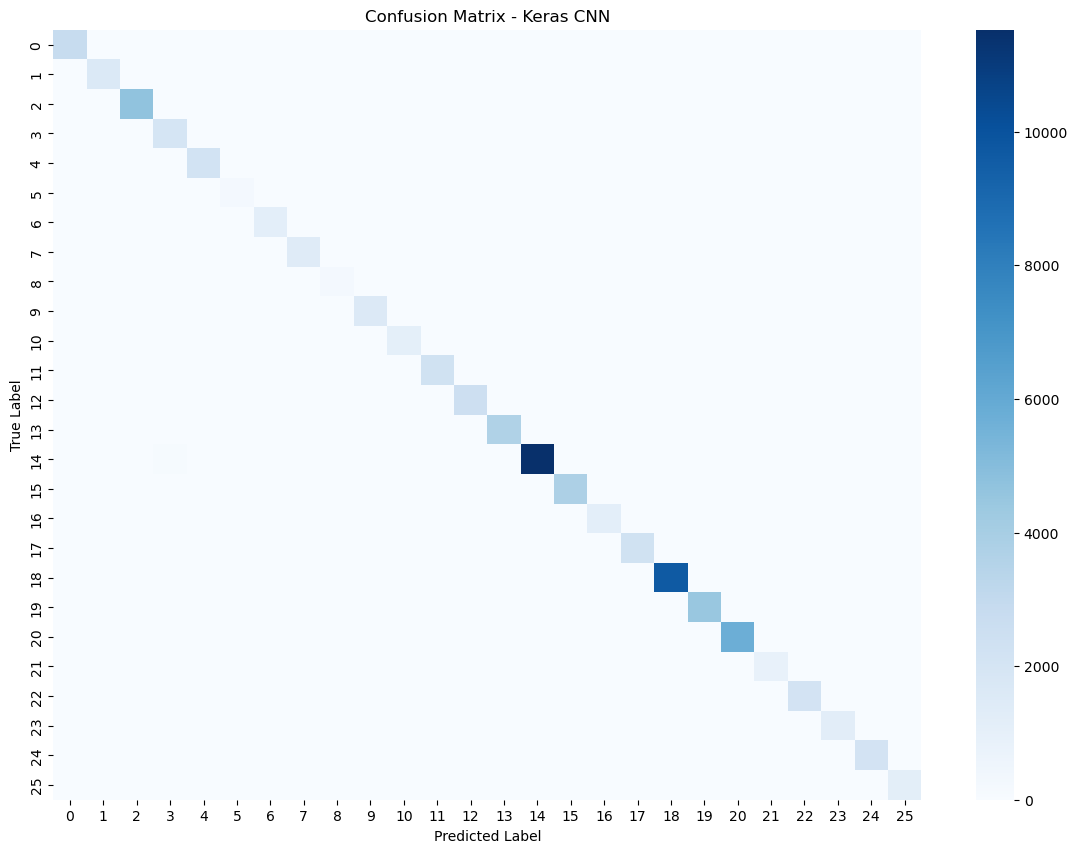

In [11]:
# Predict classes
y_pred = model.predict(test_images) # Generate predictions for the testing dataset
y_pred_classes = np.argmax(y_pred, axis=1) # Determine the predicted class for each test image

# Convert one-hot encoded labels back to class numbers
y_true = np.argmax(test_labels, axis=1)

# Classification Report
print("Classification Report:")
print(classification_report(y_true, y_pred_classes))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Display the confusion matrix as a heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(cm, annot=False, cmap="Blues")
plt.title("Confusion Matrix - Keras CNN")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

## Results:
1. Trained CNN has achieved  **test accuracy of approximately 99.00%** with  **test loss of 0.0373**, reflecting excellent performance on the unseen A–Z Handwritten Alphabet test dataset. 
2. Classification report shows that, CNN achieved **99% overall accuracy** with precision, recall, and F1-scores close to **0.99** for almost all alphabet classes.
3. The confusion matrix shows that nearly all predictions are concentrated along the main diagonal, indicating that the CNN correctly classified the vast majority of handwritten alphabet images. Only a few off-diagonal values represent minor misclassifications between visually similar letters, confirming the model's excellent classification performance.